In [2]:
import numpy as np
import time
import math 
import matplotlib.pyplot as plt

In [3]:
def tanh(x):
     return np.tanh(x)

def derivative(x):
     return 1 - x**2

input = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])

output = np.array([
    [0],
    [1],
    [1],
    [0]
])

# Inicialização aleatória dos pesos
np.random.seed(1)

# Entrada 2 | 3 neurônios na camada oculta
w0 = 2 * np.random.random((2, 3)) - 1

# 3 neurônios ocultos | 1 neurônio de saída
w1 = 2 * np.random.random((3, 1)) - 1

epochs = 10000

learning_rate = 0.1

errors = []

In [4]:
for i in range(epochs):

    # Forward
    hidden_input = np.dot(input, w0)
    hidden_layer = tanh(hidden_input)

    output_input = np.dot(hidden_layer, w1)
    output_layer = tanh(output_input)

    # Erro
    error = output - output_layer

    if i % 1000 == 0:
        time.sleep(1)
        print(f"Época {i} - Capturando erros: {np.mean(np.abs(error)):.4f}")
      
    # Backpropagation
    delta_output = error * derivative(output_layer)

    error_hidden = delta_output.dot(w1.T)
    delta_hidden = error_hidden * derivative(hidden_layer)

    # Ajuste dos pesos
    w1 += hidden_layer.T.dot(delta_output) * learning_rate
    w0 += input.T.dot(delta_hidden) * learning_rate

    errors.append(np.mean(np.abs(error)))  # salva o erro



Época 0 - Capturando erros: 0.4730
Época 1000 - Capturando erros: 0.0241
Época 2000 - Capturando erros: 0.0143
Época 3000 - Capturando erros: 0.0110
Época 4000 - Capturando erros: 0.0093
Época 5000 - Capturando erros: 0.0081
Época 6000 - Capturando erros: 0.0073
Época 7000 - Capturando erros: 0.0067
Época 8000 - Capturando erros: 0.0062
Época 9000 - Capturando erros: 0.0058


In [5]:
print("\nResultado binário:")
print((output_layer > 0.5).astype(int))

print("\nSaída esperada:")
print(output)

# Teste final
print("\nResultado final:")
print(output_layer)


Resultado binário:
[[0]
 [1]
 [1]
 [0]]

Saída esperada:
[[0]
 [1]
 [1]
 [0]]

Resultado final:
[[0.00000000e+00]
 [9.89110422e-01]
 [9.89122690e-01]
 [2.18376473e-04]]


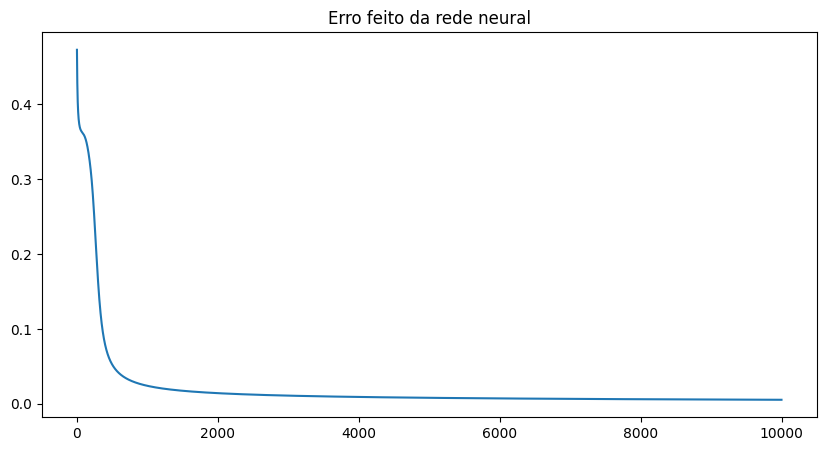

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(errors)
plt.title("Erro da rede neural")
plt.show()